<a href="https://colab.research.google.com/github/ZeninKris/zmm-movilidad-predictiva/blob/main/notebooks/06_FE_zonas_industriales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06 — Feature Engineering: Zonas Industriales

## Objetivo
Construir un feature espacial que relacione cada siniestro de OCISEVI
con su zona industrial más cercana, usando coordenadas exactas del DENUE
como base geográfica.

## El problema central
Los siniestros tienen coordenadas exactas (57% de cobertura, 100% en 2024).
Las zonas industriales no tienen geometría oficial disponible.
Hay que inferir la geometría de las zonas desde los propios datos del DENUE.

## Método
1. DBSCAN sobre coordenadas DENUE → clusters = zonas densas (Tipo A)
2. Empresas ancla aisladas 251+ empleados → zonas individuales (Tipo B/C)
3. Merge con CSV curado de Adrián → nombres formales a clusters
4. Haversine siniestros → zona más cercana con buffer de 2km
5. Índice de masa laboral por zona → proxy de intensidad de flujo laboral

## Features construidas
- `dist_industrial_promedio` — distancia promedio siniestros→zona por hora
- `dist_industrial_minima`   — siniestro más cercano a zona industrial esa hora
- `siniestros_en_zona`       — conteo siniestros dentro de 2km por hora
- `masa_laboral_max`         — peso laboral de la zona más activa esa hora

## Insumos
- `denue_industrial_zmm_limpio.csv` — 2,187 empresas con coordenadas
- `rativ_unificado.csv` — 203,890 siniestros (57% con coords parseables)
- `parques_industriales_maestro_v3.csv` — 55 parques curados por Adrián
- `super_tabla_completa.csv` — esqueleto horario 35,064 × 25 columnas

## Municipios del modelo — 8 municipios industriales
Apodaca, Guadalupe, Santa Catarina, General Escobedo,
San Nicolás de los Garza, García, Pesquería, Juárez

In [18]:
# Celda diagnóstico — correr en Colab antes de Celda 1
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Proyecto_ZMM/'

denue = pd.read_csv('/content/drive/MyDrive/Proyecto_ZMM/data_processed/denue_industrial_zmm_limpio.csv')
print("Shape:", denue.shape)
print("Columnas:", list(denue.columns))
print("\nMunicipios:")
print(denue.iloc[:,0].value_counts().head(10) if 'municipio' not in denue.columns
      else denue['municipio'].value_counts().head(10))
print("\nPrimeras 3 filas:")
print(denue.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (2187, 42)
Columnas: ['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']

Municipios:
municipio
Apodaca                     533
Monterrey                   452
Guadalupe                   280
Santa Catarina              244
General Escobedo            208
San Nicolás de los Garza    204
García                       80
San Pedro Garza García       48
Salinas Victoria             45
Pesquería

In [19]:
# Diagnóstico San Nicolás
import pandas as pd

denue = pd.read_csv(BASE + 'data_processed/denue_industrial_zmm_limpio.csv')
rativ = pd.read_csv(BASE + 'data_processed/rativ_unificado.csv')

# 1. DENUE — ¿qué sectores dominan en San Nicolás?
sn = denue[denue['municipio'] == 'San Nicolás de los Garza']
print("=== DENUE San Nicolás — sectores SCIAN ===")
print(sn['codigo_act'].astype(str).str[:2].value_counts().head(10).to_dict())
print(f"Total establecimientos: {len(sn)}")

# 2. OCISEVI — ¿cuántos siniestros tiene vs los municipios del modelo?
# El código INEGI de San Nicolás es 39
print("\n=== OCISEVI — siniestros por municipio ===")
print(rativ['MUNICIPIO'].value_counts().head(12).to_dict())

/tmp/ipykernel_3563/3168802664.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  rativ = pd.read_csv(BASE + 'data_processed/rativ_unificado.csv')


=== DENUE San Nicolás — sectores SCIAN ===
{'33': 79, '48': 53, '32': 48, '31': 19, '49': 5}
Total establecimientos: 204

=== OCISEVI — siniestros por municipio ===
{39: 97953, 46: 28631, 19: 20115, 6: 11628, 21: 11397, 48: 8909, 26: 8742, 18: 6477, 31: 3662, 49: 3541, 41: 2835}


In [20]:
# Verificar código INEGI de San Nicolás en OCISEVI
import pandas as pd
rativ = pd.read_csv(BASE + 'data_processed/rativ_unificado.csv', low_memory=False)

# Ver qué municipio corresponde al código 46
print(rativ[rativ['MUNICIPIO'] == 46][['MUNICIPIO']].drop_duplicates())

# Y ver todos los códigos con su conteo para confirmar el mapeo
print("\nCódigos únicos en OCISEVI:")
print(rativ['MUNICIPIO'].value_counts().to_dict())

      MUNICIPIO
4796         46

Códigos únicos en OCISEVI:
{39: 97953, 46: 28631, 19: 20115, 6: 11628, 21: 11397, 48: 8909, 26: 8742, 18: 6477, 31: 3662, 49: 3541, 41: 2835}


In [21]:
# Verificación previa a DBSCAN
denue = pd.read_csv(BASE + 'data_processed/denue_industrial_zmm_limpio.csv')
print("Columnas:", denue.columns.tolist())
print("Shape:", denue.shape)
print("\nPrimeras 2 filas:")
print(denue.head(2))

Columnas: ['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']
Shape: (2187, 42)

Primeras 2 filas:
        id                          clee                  nom_estab  \
0  6236242  19039311811000077000002859S9  1081 CAJA BIMBO MONTERREY   
1  6235101  19039311910000197002002859S5        1083 CAJA SANISSIMO   

       raz_social  codigo_act               nombre_act             per_ocu  \
0  BIMBO SA DE CV      311811  Panificación industrial  251 y más personas   
1  BIMBO SA DE CV      311910   Elaboración de botanas  251 

In [22]:
# ============================================================
# NB06 — Celda 1: DBSCAN sobre DENUE → centroides de parques
# ============================================================
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from google.colab import drive

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Proyecto_ZMM/'

denue = pd.read_csv(BASE + 'data_processed/denue_industrial_zmm_limpio.csv')

# 8 municipios industriales validados (7 originales + San Nicolás confirmado)
municipios_industriales = [
    'Apodaca', 'Guadalupe', 'Santa Catarina',
    'General Escobedo', 'García', 'Pesquería', 'Juárez',
    'San Nicolás de los Garza'
]

denue_ind = denue[denue['municipio'].isin(municipios_industriales)].copy()
print(f"Establecimientos en 8 municipios: {len(denue_ind)}")
print(denue_ind['municipio'].value_counts().to_dict())

coords = denue_ind[['latitud', 'longitud']].values

# eps=0.005 ≈ 500m en grados decimales. min_samples=3: mínimo 3 empresas por cluster.
db = DBSCAN(eps=0.005, min_samples=3, metric='euclidean').fit(coords)
denue_ind = denue_ind.copy()
denue_ind['cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_ruido    = (db.labels_ == -1).sum()

print(f"\nClusters encontrados: {n_clusters}")
print(f"Establecimientos en algún cluster: {len(denue_ind) - n_ruido}")
print(f"Establecimientos aislados (ruido): {n_ruido}")

# Centroide y tamaño de cada cluster
centroides = (
    denue_ind[denue_ind['cluster'] >= 0]
    .groupby(['cluster', 'municipio'])
    .agg(
        lat_centroide = ('latitud',  'mean'),
        lon_centroide = ('longitud', 'mean'),
        num_empresas  = ('id',       'count'),
        lat_min       = ('latitud',  'min'),
        lat_max       = ('latitud',  'max'),
        lon_min       = ('longitud', 'min'),
        lon_max       = ('longitud', 'max'),
    )
    .reset_index()
)

centroides['radio_aprox_m'] = (
    ((centroides['lat_max'] - centroides['lat_min'])**2 +
     (centroides['lon_max'] - centroides['lon_min'])**2)**0.5 * 111000 / 2
).round(0)

centroides = centroides.sort_values('num_empresas', ascending=False)

print(f"\n=== TOP 20 CLUSTERS POR TAMAÑO ===")
print(centroides[['cluster','municipio','lat_centroide','lon_centroide',
                   'num_empresas','radio_aprox_m']].head(20).to_string(index=False))

centroides.to_csv(BASE + 'data_processed/parques_denue_clusters.csv', index=False)
print(f"\n✅ Guardado: parques_denue_clusters.csv ({len(centroides)} clusters)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Establecimientos en 8 municipios: 1625
{'Apodaca': 533, 'Guadalupe': 280, 'Santa Catarina': 244, 'General Escobedo': 208, 'San Nicolás de los Garza': 204, 'García': 80, 'Pesquería': 45, 'Juárez': 31}

Clusters encontrados: 92
Establecimientos en algún cluster: 1408
Establecimientos aislados (ruido): 217

=== TOP 20 CLUSTERS POR TAMAÑO ===
 cluster                municipio  lat_centroide  lon_centroide  num_empresas  radio_aprox_m
       4                  Apodaca      25.757507    -100.191421           272         4923.0
       6           Santa Catarina      25.680585    -100.456014           142         4575.0
      30                  Apodaca      25.773118    -100.141237            95         2726.0
       9 San Nicolás de los Garza      25.720234    -100.284495            62         2619.0
       3         General Escobedo      25.805983    -100.350182  

In [23]:
# NB06 — Celda 2: Visualización de clusters DBSCAN
import folium
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

# Re-construir denue_ind con labels (por si el kernel perdió la variable)
municipios_industriales = [
    'Apodaca', 'Guadalupe', 'Santa Catarina',
    'General Escobedo', 'García', 'Pesquería', 'Juárez',
    'San Nicolás de los Garza'
]

denue = pd.read_csv(BASE + 'data_processed/denue_industrial_zmm_limpio.csv')
denue_ind = denue[denue['municipio'].isin(municipios_industriales)].copy()

coords = denue_ind[['latitud', 'longitud']].values
db = DBSCAN(eps=0.005, min_samples=3, metric='euclidean').fit(coords)
denue_ind['cluster'] = db.labels_

centroides = pd.read_csv(BASE + 'data_processed/parques_denue_clusters.csv')

# Colores por municipio
colores = {
    'Apodaca': 'blue', 'Guadalupe': 'green', 'Santa Catarina': 'red',
    'General Escobedo': 'purple', 'San Nicolás de los Garza': 'orange',
    'García': 'darkred', 'Pesquería': 'cadetblue', 'Juárez': 'darkgreen'
}

mapa = folium.Map(location=[25.72, -100.28], zoom_start=11)

# Puntos individuales
for _, row in denue_ind.iterrows():
    color = colores.get(row['municipio'], 'gray')
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.4,
        tooltip=f"{row['nom_estab']} — {row['municipio']} — cluster {row['cluster']}"
    ).add_to(mapa)

# Centroides top 20 con círculo de radio real
top20 = centroides.sort_values('num_empresas', ascending=False).head(20)
for _, row in top20.iterrows():
    folium.Marker(
        location=[row['lat_centroide'], row['lon_centroide']],
        tooltip=f"Cluster {row['cluster']} — {row['municipio']} — {row['num_empresas']} empresas — r≈{row['radio_aprox_m']:.0f}m",
        icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(mapa)
    folium.Circle(
        location=[row['lat_centroide'], row['lon_centroide']],
        radius=float(row['radio_aprox_m']),
        color='black',
        fill=False,
        weight=1.5
    ).add_to(mapa)

mapa.save(BASE + 'data_processed/clusters_dbscan_viz.html')
print("✅ Mapa guardado en Drive → data_processed/clusters_dbscan_viz.html")

✅ Mapa guardado en Drive → data_processed/clusters_dbscan_viz.html


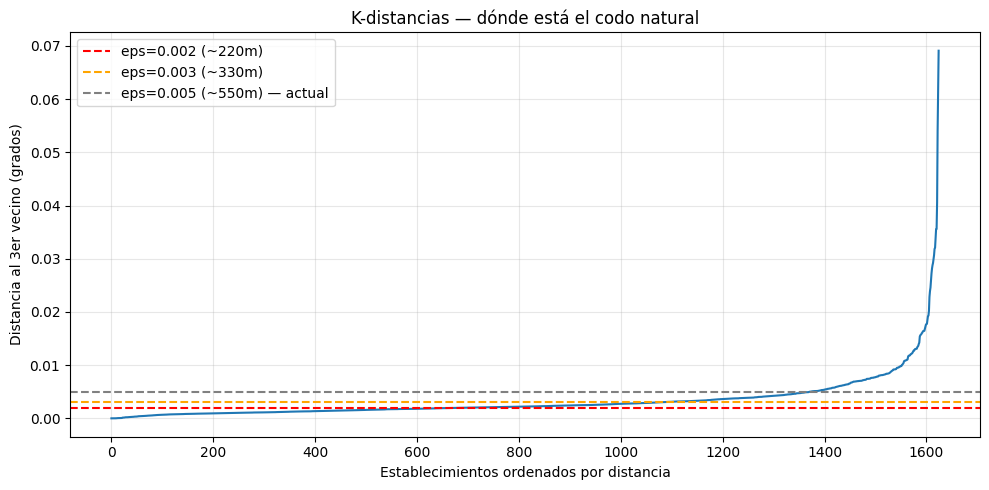

✅ Gráfica guardada


In [24]:
# NB06 — Celda 3: K-distancias para tuning de eps
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

coords = denue_ind[['latitud', 'longitud']].values

# Calculamos distancia al 3er vecino más cercano (mismo min_samples que usaremos)
neighbors = NearestNeighbors(n_neighbors=3, metric='euclidean')
neighbors.fit(coords)
distancias, _ = neighbors.kneighbors(coords)

# La columna [-1] es la distancia al vecino más lejano (el 3ro)
dist_sorted = np.sort(distancias[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(dist_sorted)
plt.axhline(y=0.002, color='red',   linestyle='--', label='eps=0.002 (~220m)')
plt.axhline(y=0.003, color='orange', linestyle='--', label='eps=0.003 (~330m)')
plt.axhline(y=0.005, color='gray',  linestyle='--', label='eps=0.005 (~550m) — actual')
plt.xlabel('Establecimientos ordenados por distancia')
plt.ylabel('Distancia al 3er vecino (grados)')
plt.title('K-distancias — dónde está el codo natural')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE + 'data_processed/kdistancias_dbscan.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

In [25]:
# NB06 — Celda 4: DBSCAN con eps ajustado
from sklearn.cluster import DBSCAN
import pandas as pd

denue = pd.read_csv(BASE + 'data_processed/denue_industrial_zmm_limpio.csv')
municipios_industriales = [
    'Apodaca', 'Guadalupe', 'Santa Catarina',
    'General Escobedo', 'García', 'Pesquería', 'Juárez',
    'San Nicolás de los Garza'
]
denue_ind = denue[denue['municipio'].isin(municipios_industriales)].copy()
coords = denue_ind[['latitud', 'longitud']].values

db = DBSCAN(eps=0.002, min_samples=3, metric='euclidean').fit(coords)
denue_ind['cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_ruido    = (db.labels_ == -1).sum()

print(f"Clusters encontrados: {n_clusters}")
print(f"En algún cluster: {len(denue_ind) - n_ruido}")
print(f"Ruido (aislados): {n_ruido}")

centroides = (
    denue_ind[denue_ind['cluster'] >= 0]
    .groupby(['cluster', 'municipio'])
    .agg(
        lat_centroide = ('latitud',  'mean'),
        lon_centroide = ('longitud', 'mean'),
        num_empresas  = ('id',       'count'),
        lat_min       = ('latitud',  'min'),
        lat_max       = ('latitud',  'max'),
        lon_min       = ('longitud', 'min'),
        lon_max       = ('longitud', 'max'),
    )
    .reset_index()
)

centroides['radio_aprox_m'] = (
    ((centroides['lat_max'] - centroides['lat_min'])**2 +
     (centroides['lon_max'] - centroides['lon_min'])**2)**0.5 * 111000 / 2
).round(0)

centroides = centroides.sort_values('num_empresas', ascending=False)

print(f"\n=== TOP 20 CLUSTERS ===")
print(centroides[['cluster','municipio','lat_centroide','lon_centroide',
                   'num_empresas','radio_aprox_m']].head(20).to_string(index=False))

centroides.to_csv(BASE + 'data_processed/parques_denue_clusters.csv', index=False)
print(f"\n✅ {len(centroides)} clusters guardados")

Clusters encontrados: 154
En algún cluster: 844
Ruido (aislados): 781

=== TOP 20 CLUSTERS ===
 cluster                municipio  lat_centroide  lon_centroide  num_empresas  radio_aprox_m
      30                  Apodaca      25.753451    -100.193706            39          771.0
      11 San Nicolás de los Garza      25.723756    -100.208162            29          688.0
      21           Santa Catarina      25.669833    -100.446445            21          607.0
       9           Santa Catarina      25.689385    -100.475049            20          651.0
      53                  Apodaca      25.759106    -100.175652            20          426.0
       7                  Apodaca      25.745018    -100.216300            19          553.0
      13         General Escobedo      25.802697    -100.349690            18          500.0
      34                  Apodaca      25.774482    -100.170100            15          560.0
      25                  Apodaca      25.765441    -100.195770     

In [26]:
# NB06 — Celda 5: DBSCAN eps=0.003 — punto medio validado por k-distancias
db = DBSCAN(eps=0.003, min_samples=3, metric='euclidean').fit(coords)
denue_ind['cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_ruido    = (db.labels_ == -1).sum()

print(f"Clusters encontrados: {n_clusters}")
print(f"En algún cluster: {len(denue_ind) - n_ruido} ({(len(denue_ind)-n_ruido)/len(denue_ind)*100:.0f}%)")
print(f"Ruido (aislados): {n_ruido}")

centroides = (
    denue_ind[denue_ind['cluster'] >= 0]
    .groupby(['cluster', 'municipio'])
    .agg(
        lat_centroide = ('latitud',  'mean'),
        lon_centroide = ('longitud', 'mean'),
        num_empresas  = ('id',       'count'),
        lat_min       = ('latitud',  'min'),
        lat_max       = ('latitud',  'max'),
        lon_min       = ('longitud', 'min'),
        lon_max       = ('longitud', 'max'),
    )
    .reset_index()
)

centroides['radio_aprox_m'] = (
    ((centroides['lat_max'] - centroides['lat_min'])**2 +
     (centroides['lon_max'] - centroides['lon_min'])**2)**0.5 * 111000 / 2
).round(0)

centroides = centroides.sort_values('num_empresas', ascending=False)

print(f"\n=== TOP 20 CLUSTERS ===")
print(centroides[['cluster','municipio','lat_centroide','lon_centroide',
                   'num_empresas','radio_aprox_m']].head(20).to_string(index=False))

centroides.to_csv(BASE + 'data_processed/parques_denue_clusters.csv', index=False)
print(f"\n✅ {len(centroides)} clusters guardados")

Clusters encontrados: 131
En algún cluster: 1173 (72%)
Ruido (aislados): 452

=== TOP 20 CLUSTERS ===
 cluster                municipio  lat_centroide  lon_centroide  num_empresas  radio_aprox_m
      26                  Apodaca      25.754325    -100.194510            79         1903.0
      52                  Apodaca      25.778621    -100.140163            46         1410.0
       3         General Escobedo      25.806346    -100.350182            42          929.0
       7           Santa Catarina      25.672206    -100.445743            38         1072.0
      14 San Nicolás de los Garza      25.723569    -100.208723            33          739.0
       9                  Apodaca      25.745072    -100.216558            33          933.0
      45                   García      25.789262    -100.442187            33          960.0
      19 San Nicolás de los Garza      25.719406    -100.285557            29         1284.0
       2                Guadalupe      25.704424    -100.2079

In [27]:
# NB06 — Celda 6: Visualización con eps=0.003
import folium

colores = {
    'Apodaca': 'blue', 'Guadalupe': 'green', 'Santa Catarina': 'red',
    'General Escobedo': 'purple', 'San Nicolás de los Garza': 'orange',
    'García': 'darkred', 'Pesquería': 'cadetblue', 'Juárez': 'darkgreen'
}

mapa = folium.Map(location=[25.72, -100.28], zoom_start=11)

for _, row in denue_ind.iterrows():
    color = colores.get(row['municipio'], 'gray')
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.4,
        tooltip=f"{row['nom_estab']} — {row['municipio']} — cluster {row['cluster']}"
    ).add_to(mapa)

top20 = centroides.sort_values('num_empresas', ascending=False).head(20)
for _, row in top20.iterrows():
    folium.Marker(
        location=[row['lat_centroide'], row['lon_centroide']],
        tooltip=f"Cluster {row['cluster']} — {row['municipio']} — {row['num_empresas']} empresas — r≈{row['radio_aprox_m']:.0f}m",
        icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(mapa)
    folium.Circle(
        location=[row['lat_centroide'], row['lon_centroide']],
        radius=float(row['radio_aprox_m']),
        color='black',
        fill=False,
        weight=1.5
    ).add_to(mapa)

mapa.save(BASE + 'data_processed/clusters_dbscan_viz_003.html')
print("✅ Mapa guardado: clusters_dbscan_viz_003.html")

✅ Mapa guardado: clusters_dbscan_viz_003.html


In [29]:
# Recrear tiene_coordenadas y ver formato de Referencia
rativ['tiene_coordenadas'] = (
    rativ['Referencia'].notna() &
    (rativ['Referencia'].astype(str).str.strip() != '99')
)

print(f"Total siniestros: {len(rativ):,}")
print(f"Con coordenadas: {rativ['tiene_coordenadas'].sum():,}")
print(f"Sin coordenadas: {(~rativ['tiene_coordenadas']).sum():,}")

print(f"\nEjemplos de Referencia CON coordenadas:")
print(rativ[rativ['tiene_coordenadas']]['Referencia'].head(10).tolist())

print(f"\nEjemplos de Referencia SIN coordenadas:")
print(rativ[~rativ['tiene_coordenadas']]['Referencia'].head(5).tolist())

Total siniestros: 203,890
Con coordenadas: 119,013
Sin coordenadas: 84,877

Ejemplos de Referencia CON coordenadas:
['25.684746, -100.118071', 'PUENTE', 'OFICINAS DE VENTAS SAN CRISTOBAL', '25.62807, -100.07143', 'KM 1', 'LAS ADJUNTAS', 'EDIFICIO ADMINISTRATIVO MUNICIPAL', 'FRENTE AL ADILLON', 'POR LA PEDRERA', 'CRUCE SANTA CLARA ']

Ejemplos de Referencia SIN coordenadas:
['99', '99', '99', '99', '99']


In [30]:
# Parsear coordenadas reales de la columna Referencia
import re

def extraer_coordenadas(valor):
    """Devuelve (lat, lon) si el valor es una coordenada numérica, si no (NaN, NaN)"""
    if pd.isna(valor):
        return np.nan, np.nan
    patron = r'^(-?\d{1,3}\.\d+),\s*(-?\d{1,3}\.\d+)$'
    match = re.match(patron, str(valor).strip())
    if match:
        return float(match.group(1)), float(match.group(2))
    return np.nan, np.nan

rativ[['lat', 'lon']] = rativ['Referencia'].apply(
    lambda v: pd.Series(extraer_coordenadas(v))
)

tiene_coord_real = rativ['lat'].notna()
print(f"Con coordenada numérica parseable: {tiene_coord_real.sum():,}")
print(f"Sin coordenada parseable:          {(~tiene_coord_real).sum():,}")
print(f"\nPorcentaje real con coords: {tiene_coord_real.sum()/len(rativ)*100:.1f}%")

print(f"\nPor año:")
print(rativ.groupby('Año')['lat'].apply(lambda x: x.notna().sum()).to_dict())

print(f"\nEjemplos de coordenadas parseadas:")
print(rativ[tiene_coord_real][['Referencia','lat','lon']].head(5).to_string())

Con coordenada numérica parseable: 116,659
Sin coordenada parseable:          87,231

Porcentaje real con coords: 57.2%

Por año:
{2023: 13357, 2024: 67956, 2025: 35346}

Ejemplos de coordenadas parseadas:
                 Referencia        lat         lon
32   25.684746, -100.118071  25.684746 -100.118071
89     25.62807, -100.07143  25.628070 -100.071430
465  25.664114, -100.361856  25.664114 -100.361856
521  25.662549, -100.351452  25.662549 -100.351452
563  25.657465, -100.371758  25.657465 -100.371758


In [33]:
# NB06 — Celda 8: Haversine siniestros → zona industrial más cercana
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Centroides únicos (colapsar filas duplicadas por cluster que cruza municipios)
centroides_unicos = (
    centroides.groupby('cluster')
    .agg(lat=('lat_centroide','mean'), lon=('lon_centroide','mean'),
         num_empresas=('num_empresas','sum'), municipio=('municipio','first'))
    .reset_index()
)
print(f"Centroides únicos: {len(centroides_unicos)}")

# Solo siniestros con coordenadas reales
rativ_geo = rativ[rativ['lat'].notna()].copy()
print(f"Siniestros que entran a Haversine: {len(rativ_geo):,}")

# Calcular distancia al cluster más cercano
lats_c = centroides_unicos['lat'].values
lons_c = centroides_unicos['lon'].values
ids_c  = centroides_unicos['cluster'].values

dist_min    = []
cluster_min = []

for lat, lon in zip(rativ_geo['lat'].values, rativ_geo['lon'].values):
    distancias = [haversine(lat, lon, lc, lnc) for lc, lnc in zip(lats_c, lons_c)]
    idx = int(np.argmin(distancias))
    dist_min.append(round(distancias[idx]))
    cluster_min.append(int(ids_c[idx]))

rativ_geo['dist_zona_industrial_m'] = dist_min
rativ_geo['cluster_mas_cercano']    = cluster_min
rativ_geo['en_zona_industrial']     = (rativ_geo['dist_zona_industrial_m'] <= 2000).astype(int)

print(f"\n=== DISTRIBUCIÓN DE DISTANCIAS ===")
print(rativ_geo['dist_zona_industrial_m'].describe().round(0))

total_en_zona = rativ_geo['en_zona_industrial'].sum()
pct_en_zona   = rativ_geo['en_zona_industrial'].mean() * 100
print(f"\nSiniestros dentro de 2km de zona industrial: {total_en_zona:,}")
print(f"Porcentaje: {pct_en_zona:.1f}%")

print(f"\nPor año:")
print(rativ_geo.groupby('Año')['en_zona_industrial'].mean().round(3).mul(100))

Centroides únicos: 131
Siniestros que entran a Haversine: 116,659

=== DISTRIBUCIÓN DE DISTANCIAS ===
count      116659.0
mean         4042.0
std         48079.0
min             5.0
25%           982.0
50%          2783.0
75%          5556.0
max      13905399.0
Name: dist_zona_industrial_m, dtype: float64

Siniestros dentro de 2km de zona industrial: 49,060
Porcentaje: 42.1%

Por año:
Año
2023    63.2
2024    39.0
2025    40.0
Name: en_zona_industrial, dtype: float64


In [34]:
# NB06 — Celda 9: Filtrar coords inválidas + re-calcular Haversine
# Bounding box conservador de la ZMM
LAT_MIN, LAT_MAX = 25.4,  26.1
LON_MIN, LON_MAX = -100.7, -99.8

coords_validas = (
    rativ_geo['lat'].between(LAT_MIN, LAT_MAX) &
    rativ_geo['lon'].between(LON_MIN, LON_MAX)
)

print(f"Coords dentro de bounding box ZMM: {coords_validas.sum():,}")
print(f"Coords fuera (basura): {(~coords_validas).sum():,}")

rativ_geo = rativ_geo[coords_validas].copy()

# Re-calcular Haversine solo con coords limpias
dist_min    = []
cluster_min = []

for lat, lon in zip(rativ_geo['lat'].values, rativ_geo['lon'].values):
    distancias = [haversine(lat, lon, lc, lnc) for lc, lnc in zip(lats_c, lons_c)]
    idx = int(np.argmin(distancias))
    dist_min.append(round(distancias[idx]))
    cluster_min.append(int(ids_c[idx]))

rativ_geo['dist_zona_industrial_m'] = dist_min
rativ_geo['cluster_mas_cercano']    = cluster_min
rativ_geo['en_zona_industrial']     = (rativ_geo['dist_zona_industrial_m'] <= 2000).astype(int)

print(f"\n=== DISTANCIAS LIMPIAS ===")
print(rativ_geo['dist_zona_industrial_m'].describe().round(0))

total = rativ_geo['en_zona_industrial'].sum()
pct   = rativ_geo['en_zona_industrial'].mean() * 100
print(f"\nSiniestros dentro de 2km: {total:,}")
print(f"Porcentaje: {pct:.1f}%")

print(f"\nPor año:")
print(rativ_geo.groupby('Año')['en_zona_industrial'].mean().round(3).mul(100))

Coords dentro de bounding box ZMM: 115,845
Coords fuera (basura): 814

=== DISTANCIAS LIMPIAS ===
count    115845.0
mean       3548.0
std        3475.0
min           5.0
25%         975.0
50%        2737.0
75%        5479.0
max       27874.0
Name: dist_zona_industrial_m, dtype: float64

Siniestros dentro de 2km: 49,060
Porcentaje: 42.3%

Por año:
Año
2023    63.7
2024    39.2
2025    40.4
Name: en_zona_industrial, dtype: float64


In [35]:
# Diagnóstico — parques_industriales_maestro_v3.csv
import pandas as pd

parques = pd.read_csv(BASE + 'data_raw/parques_industriales_maestro_v3.csv')
print(f"Shape: {parques.shape}")
print(f"\nColumnas: {parques.columns.tolist()}")
print(f"\nMunicipios presentes:")
print(parques['municipio'].value_counts().to_dict() if 'municipio' in parques.columns else "columna municipio no encontrada")
print(f"\nPrimeras 5 filas:")
print(parques.head(5).to_string())
print(f"\nNulos por columna:")
print(parques.isnull().sum())

Shape: (56, 7)

Columnas: ['nombre_parque', 'municipio', 'latitud', 'longitud', 'hectareas_aprox', 'fuente', 'coord_verificada']

Municipios presentes:
{'Guadalupe': 14, 'Apodaca': 12, 'Escobedo': 12, 'Santa Catarina': 8, 'Pesquería': 5, 'García': 2, 'Juárez': 2, 'Salinas Victoria': 1}

Primeras 5 filas:
                         nombre_parque municipio    latitud    longitud  hectareas_aprox  fuente  coord_verificada
0          Parque Industrial Monterrey   Apodaca  25.772428 -100.168106            104.5  Adrian              True
1    Parque Industrial FINSA Monterrey   Apodaca  25.787652 -100.137964             70.0  Adrian              True
2          Parque Industrial Apodaca I   Apodaca  25.748500 -100.198300             35.1  Adrian              True
3         Parque Industrial Apodaca II   Apodaca  25.753000 -100.185000              NaN  Adrian              True
4  Parque Industrial Avante Aeropuerto   Apodaca  25.749850 -100.132677             25.0  Adrian              True

Nul

In [36]:
# NB06 — Paso 1: Diagnóstico empresas ancla fuera de clusters
# Necesitamos reconstruir denue_ind con labels de eps=0.003
from sklearn.cluster import DBSCAN
import pandas as pd

denue = pd.read_csv(BASE + 'data_processed/denue_industrial_zmm_limpio.csv')
municipios_industriales = [
    'Apodaca', 'Guadalupe', 'Santa Catarina',
    'General Escobedo', 'García', 'Pesquería', 'Juárez',
    'San Nicolás de los Garza'
]
denue_ind = denue[denue['municipio'].isin(municipios_industriales)].copy()
coords = denue_ind[['latitud', 'longitud']].values
db = DBSCAN(eps=0.003, min_samples=3, metric='euclidean').fit(coords)
denue_ind['cluster'] = db.labels_

# Empresas ancla = 251+ empleados fuera de cualquier cluster
ruido = denue_ind[denue_ind['cluster'] == -1].copy()
anclas = ruido[ruido['per_ocu'] == '251 y más personas']

print(f"Total en ruido (aislados): {len(ruido)}")
print(f"De esos, con 251+ empleados: {len(anclas)}")
print(f"\n=== EMPRESAS ANCLA PERDIDAS ===")
print(anclas[['nom_estab','municipio','latitud','longitud']].to_string())

print(f"\nDistribución per_ocu en ruido:")
print(ruido['per_ocu'].value_counts())

Total en ruido (aislados): 452
De esos, con 251+ empleados: 112

=== EMPRESAS ANCLA PERDIDAS ===
                                                      nom_estab                 municipio    latitud    longitud
40                                          DELICIAS DEL CONTRY                 Guadalupe  25.666067 -100.263407
64                                               GRIFFITH FOODS            Santa Catarina  25.685173 -100.463610
71                                                    HERSHEY S          General Escobedo  25.820677 -100.363901
131                                      PASTELERIA LETY MATRIZ  San Nicolás de los Garza  25.715269 -100.268133
170                                                    SPRAYLAB            Santa Catarina  25.696691 -100.485403
173                                      SUKARNE AGROINDUSTRIAL          General Escobedo  25.823866 -100.361345
267                                                        CATO            Santa Catarina  25.665024 -100.448834

In [37]:
# NB06 — Paso 2: Catálogo unificado de zonas industriales
# Tipo A: clusters DBSCAN ≥5 empresas
# Tipo B: empresas ancla manufactura (SCIAN 31-33) fuera de cluster
# Tipo C: empresas ancla transporte (SCIAN 48-49) fuera de cluster

# --- Tipo A: clusters densos ---
centroides_unicos = (
    centroides.groupby('cluster')
    .agg(lat=('lat_centroide','mean'), lon=('lon_centroide','mean'),
         num_empresas=('num_empresas','sum'), municipio=('municipio','first'),
         radio_aprox_m=('radio_aprox_m','max'))
    .reset_index()
)
# Solo clusters con ≥5 empresas
tipo_a = centroides_unicos[centroides_unicos['num_empresas'] >= 5].copy()
tipo_a['tipo_zona']   = 'A_zona_densa'
tipo_a['nombre_zona'] = 'Zona_' + tipo_a['cluster'].astype(str)
tipo_a = tipo_a.rename(columns={'lat':'latitud','lon':'longitud'})
print(f"Tipo A (zonas densas ≥5 empresas): {len(tipo_a)}")

# --- Tipos B y C: empresas ancla fuera de cluster ---
ruido = denue_ind[denue_ind['cluster'] == -1].copy()
anclas = ruido[ruido['per_ocu'] == '251 y más personas'].copy()
anclas['sector'] = anclas['codigo_act'].astype(str).str[:2].astype(int)

tipo_b = anclas[anclas['sector'].between(31, 33)].copy()
tipo_b['tipo_zona']      = 'B_ancla_manufactura'
tipo_b['nombre_zona']    = tipo_b['nom_estab']
tipo_b['num_empresas']   = 1
tipo_b['radio_aprox_m']  = 500  # radio fijo conservador para empresa individual
tipo_b['cluster']        = -2   # distinguir de clusters DBSCAN y de ruido
print(f"Tipo B (anclas manufactura): {len(tipo_b)}")

tipo_c = anclas[anclas['sector'].between(48, 49)].copy()
tipo_c['tipo_zona']      = 'C_ancla_transporte'
tipo_c['nombre_zona']    = tipo_c['nom_estab']
tipo_c['num_empresas']   = 1
tipo_c['radio_aprox_m']  = 500
tipo_c['cluster']        = -3
print(f"Tipo C (anclas transporte): {len(tipo_c)}")

# --- Unificar en un solo catálogo ---
cols_comunes = ['nombre_zona','tipo_zona','municipio',
                'latitud','longitud','num_empresas','radio_aprox_m','cluster']

catalogo = pd.concat([
    tipo_a[cols_comunes],
    tipo_b[cols_comunes],
    tipo_c[cols_comunes]
], ignore_index=True)

print(f"\n=== CATÁLOGO UNIFICADO ===")
print(f"Total zonas: {len(catalogo)}")
print(f"\nPor tipo:")
print(catalogo['tipo_zona'].value_counts().to_dict())
print(f"\nPor municipio:")
print(catalogo['municipio'].value_counts().to_dict())
print(f"\nPrimeras 5 filas:")
print(catalogo[['nombre_zona','tipo_zona','municipio','num_empresas','radio_aprox_m']].head(5).to_string())

Tipo A (zonas densas ≥5 empresas): 72
Tipo B (anclas manufactura): 91
Tipo C (anclas transporte): 21

=== CATÁLOGO UNIFICADO ===
Total zonas: 184

Por tipo:
{'B_ancla_manufactura': 91, 'A_zona_densa': 72, 'C_ancla_transporte': 21}

Por municipio:
{'Apodaca': 45, 'Santa Catarina': 31, 'Guadalupe': 28, 'General Escobedo': 24, 'San Nicolás de los Garza': 24, 'Pesquería': 13, 'García': 12, 'Juárez': 7}

Primeras 5 filas:
  nombre_zona     tipo_zona         municipio  num_empresas  radio_aprox_m
0      Zona_2  A_zona_densa         Guadalupe            29         1195.0
1      Zona_3  A_zona_densa  General Escobedo            42          929.0
2      Zona_4  A_zona_densa           Apodaca            16          977.0
3      Zona_5  A_zona_densa         Guadalupe            20         1043.0
4      Zona_6  A_zona_densa         Guadalupe             9          417.0


In [38]:
# NB06 — Paso 3: Nombrar clusters Tipo A con CSV de Adrián
parques = pd.read_csv(BASE + 'data_raw/parques_industriales_maestro_v3.csv')

# Excluir Salinas Victoria — fuera del modelo
parques = parques[parques['municipio'] != 'Salinas Victoria'].copy()
print(f"Parques del CSV (sin Salinas Victoria): {len(parques)}")

# Para cada cluster Tipo A, buscar el parque más cercano dentro de 1km
def parque_mas_cercano(lat, lon, parques_df, radio_max_m=1000):
    mejor_nombre = None
    mejor_dist   = float('inf')
    for _, p in parques_df.iterrows():
        d = haversine(lat, lon, p['latitud'], p['longitud'])
        if d < mejor_dist:
            mejor_dist   = d
            mejor_nombre = p['nombre_parque']
    if mejor_dist <= radio_max_m:
        return mejor_nombre, round(mejor_dist)
    return None, round(mejor_dist)

nombres_asignados = []
distancias_match  = []

for _, zona in catalogo[catalogo['tipo_zona'] == 'A_zona_densa'].iterrows():
    nombre, dist = parque_mas_cercano(zona['latitud'], zona['longitud'], parques)
    nombres_asignados.append(nombre)
    distancias_match.append(dist)

# Aplicar nombres al catálogo
mask_a = catalogo['tipo_zona'] == 'A_zona_densa'
catalogo.loc[mask_a, 'nombre_parque_adrián'] = nombres_asignados
catalogo.loc[mask_a, 'dist_match_m']         = distancias_match

# Actualizar nombre_zona donde hubo match
mask_match = mask_a & catalogo['nombre_parque_adrián'].notna()
catalogo.loc[mask_match, 'nombre_zona'] = catalogo.loc[mask_match, 'nombre_parque_adrián']

# Resumen
con_nombre = mask_match.sum()
sin_nombre = mask_a.sum() - con_nombre

print(f"\n=== RESULTADO DEL MATCH ===")
print(f"Clusters Tipo A con nombre asignado: {con_nombre}")
print(f"Clusters Tipo A sin match (<1km):    {sin_nombre}")

print(f"\nClusters CON nombre:")
print(catalogo[mask_match][['nombre_zona','municipio','num_empresas','dist_match_m']].to_string())

print(f"\nClusters SIN nombre (zonas industriales sin parque formal cercano):")
print(catalogo[mask_a & ~mask_match][['nombre_zona','municipio','num_empresas','dist_match_m']].head(10).to_string())

Parques del CSV (sin Salinas Victoria): 55

=== RESULTADO DEL MATCH ===
Clusters Tipo A con nombre asignado: 25
Clusters Tipo A sin match (<1km):    47

Clusters CON nombre:
                                nombre_zona         municipio  num_empresas  dist_match_m
1                Parque Industrial Escobedo  General Escobedo            42          83.0
2                  Parque Industrial Kronos           Apodaca            16         512.0
3                           Kalos Guadalupe         Guadalupe            20         499.0
4                        La Silla Guadalupe         Guadalupe             9          97.0
6                     Nexxus Santa Catarina    Santa Catarina            12         272.0
8   Parque Industrial Martel Santa Catarina    Santa Catarina            26         469.0
16     STIVA Santa Catarina Industrial Park    Santa Catarina            10         426.0
17                         Avante Guadalupe         Guadalupe            24         444.0
19              

In [39]:
# NB06 — Visualización Paso 3: Catálogo con nombres asignados
import folium

mapa = folium.Map(location=[25.72, -100.28], zoom_start=11)

# Colores por tipo de zona
colores_tipo = {
    'A_zona_densa':       'blue',
    'B_ancla_manufactura':'red',
    'C_ancla_transporte': 'orange'
}

for _, zona in catalogo.iterrows():
    color = colores_tipo.get(zona['tipo_zona'], 'gray')
    tiene_nombre = (
        zona['tipo_zona'] == 'A_zona_densa' and
        not zona['nombre_zona'].startswith('Zona_')
    )

    # Círculo de influencia solo para Tipo A
    if zona['tipo_zona'] == 'A_zona_densa':
        folium.Circle(
            location=[zona['latitud'], zona['longitud']],
            radius=float(zona['radio_aprox_m']),
            color='blue' if tiene_nombre else 'gray',
            fill=True,
            fill_opacity=0.15,
            weight=2
        ).add_to(mapa)

    folium.CircleMarker(
        location=[zona['latitud'], zona['longitud']],
        radius=6 if zona['tipo_zona'] == 'A_zona_densa' else 4,
        color=color,
        fill=True,
        fill_opacity=0.8,
        tooltip=(
            f"[{zona['tipo_zona']}] {zona['nombre_zona']}\n"
            f"Municipio: {zona['municipio']}\n"
            f"Empresas: {zona['num_empresas']}"
        )
    ).add_to(mapa)

# Leyenda manual
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px; border-radius:8px;
     border:1px solid #ccc; font-size:13px;">
  <b>Tipo de zona</b><br>
  <span style="color:blue;">●</span> A — Zona densa (con nombre)<br>
  <span style="color:gray;">●</span> A — Zona densa (sin nombre)<br>
  <span style="color:red;">●</span> B — Ancla manufactura<br>
  <span style="color:orange;">●</span> C — Ancla transporte<br>
  <br>
  <b>Círculos:</b> radio real del cluster<br>
  Azul = nombrado | Gris = sin nombre formal
</div>
"""
mapa.get_root().html.add_child(folium.Element(leyenda))

mapa.save(BASE + 'data_processed/catalogo_zonas_paso3.html')
print("✅ Mapa guardado: catalogo_zonas_paso3.html")
print(f"\nResumen visual:")
print(f"  Zonas Tipo A con nombre (azul):  {(~catalogo[catalogo['tipo_zona']=='A_zona_densa']['nombre_zona'].str.startswith('Zona_')).sum()}")
print(f"  Zonas Tipo A sin nombre (gris):  {catalogo[catalogo['tipo_zona']=='A_zona_densa']['nombre_zona'].str.startswith('Zona_').sum()}")
print(f"  Anclas manufactura (rojo):       {(catalogo['tipo_zona']=='B_ancla_manufactura').sum()}")
print(f"  Anclas transporte (naranja):     {(catalogo['tipo_zona']=='C_ancla_transporte').sum()}")

✅ Mapa guardado: catalogo_zonas_paso3.html

Resumen visual:
  Zonas Tipo A con nombre (azul):  25
  Zonas Tipo A sin nombre (gris):  47
  Anclas manufactura (rojo):       91
  Anclas transporte (naranja):     21


In [40]:
# NB06 — Paso 4: Etiquetar San Nicolás + guardar catálogo final

# Los clusters Tipo A de San Nicolás quedaron como "Zona_X sin nombre"
# Les damos un nombre descriptivo basado en su ubicación aproximada
mask_sn = (catalogo['tipo_zona'] == 'A_zona_densa') & \
          (catalogo['municipio'] == 'San Nicolás de los Garza') & \
          (catalogo['nombre_zona'].str.startswith('Zona_'))

# Nombrarlos como corredor industrial con número secuencial
sn_indices = catalogo[mask_sn].index
for i, idx in enumerate(sn_indices, 1):
    catalogo.loc[idx, 'nombre_zona'] = f'Corredor Industrial SN-{i}'

print(f"Zonas San Nicolás etiquetadas: {mask_sn.sum()}")

# Resumen final del catálogo
print(f"\n=== CATÁLOGO FINAL ===")
print(f"Total zonas: {len(catalogo)}")
print(f"\nPor tipo:")
print(catalogo['tipo_zona'].value_counts().to_dict())
print(f"\nPor municipio:")
print(catalogo['municipio'].value_counts().to_dict())
print(f"\nZonas con nombre formal (Tipo A nombradas):")
tipo_a_nombradas = catalogo[
    (catalogo['tipo_zona'] == 'A_zona_densa') &
    (~catalogo['nombre_zona'].str.startswith('Zona_'))
]
print(f"  {len(tipo_a_nombradas)} de 72 clusters Tipo A")

# Guardar
catalogo.to_csv(BASE + 'data_processed/catalogo_zonas_industriales.csv', index=False)
print(f"\n✅ Guardado: catalogo_zonas_industriales.csv")
print(f"   {len(catalogo)} zonas listas para Haversine final")

Zonas San Nicolás etiquetadas: 11

=== CATÁLOGO FINAL ===
Total zonas: 184

Por tipo:
{'B_ancla_manufactura': 91, 'A_zona_densa': 72, 'C_ancla_transporte': 21}

Por municipio:
{'Apodaca': 45, 'Santa Catarina': 31, 'Guadalupe': 28, 'General Escobedo': 24, 'San Nicolás de los Garza': 24, 'Pesquería': 13, 'García': 12, 'Juárez': 7}

Zonas con nombre formal (Tipo A nombradas):
  36 de 72 clusters Tipo A

✅ Guardado: catalogo_zonas_industriales.csv
   184 zonas listas para Haversine final


In [41]:
# NB06 — Paso 5: Haversine final con catálogo completo (184 zonas)

lats_c = catalogo['latitud'].values
lons_c = catalogo['longitud'].values
nombres_c = catalogo['nombre_zona'].values
tipos_c   = catalogo['tipo_zona'].values

dist_min    = []
zona_min    = []
tipo_min    = []

for lat, lon in zip(rativ_geo['lat'].values, rativ_geo['lon'].values):
    distancias = [haversine(lat, lon, lc, lnc) for lc, lnc in zip(lats_c, lons_c)]
    idx = int(np.argmin(distancias))
    dist_min.append(round(distancias[idx]))
    zona_min.append(nombres_c[idx])
    tipo_min.append(tipos_c[idx])

rativ_geo['dist_zona_industrial_m'] = dist_min
rativ_geo['zona_industrial_cercana'] = zona_min
rativ_geo['tipo_zona_cercana']       = tipo_min
rativ_geo['en_zona_industrial']      = (rativ_geo['dist_zona_industrial_m'] <= 2000).astype(int)

print(f"=== HAVERSINE FINAL — 184 zonas ===")
print(f"Siniestros procesados: {len(rativ_geo):,}")
print(f"\nDistancias:")
print(rativ_geo['dist_zona_industrial_m'].describe().round(0))

total = rativ_geo['en_zona_industrial'].sum()
pct   = rativ_geo['en_zona_industrial'].mean() * 100
print(f"\nDentro de 2km: {total:,} ({pct:.1f}%)")

print(f"\nPor año:")
print(rativ_geo.groupby('Año')['en_zona_industrial'].mean().mul(100).round(1))

print(f"\nTop 10 zonas con más siniestros dentro de 2km:")
top_zonas = (
    rativ_geo[rativ_geo['en_zona_industrial'] == 1]
    .groupby(['zona_industrial_cercana','tipo_zona_cercana'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(top_zonas.to_string())

=== HAVERSINE FINAL — 184 zonas ===
Siniestros procesados: 115,845

Distancias:
count    115845.0
mean       3273.0
std        3014.0
min           5.0
25%        1014.0
50%        2432.0
75%        5039.0
max       28611.0
Name: dist_zona_industrial_m, dtype: float64

Dentro de 2km: 51,735 (44.7%)

Por año:
Año
2023    68.8
2024    40.6
2025    43.4
Name: en_zona_industrial, dtype: float64

Top 10 zonas con más siniestros dentro de 2km:
zona_industrial_cercana         tipo_zona_cercana  
Zona_20                         A_zona_densa           2141
TERNIUM PLANOS GUERRERO         B_ancla_manufactura    1583
Corredor Industrial SN-11       A_zona_densa           1504
DELICIAS DEL CONTRY             B_ancla_manufactura    1419
RUGO                            B_ancla_manufactura    1206
TERNIUM REVESTIDOS UNIVERSIDAD  B_ancla_manufactura    1158
Zona_27                         A_zona_densa           1081
Zona_70                         A_zona_densa           1079
ZINC NACIONAL             

In [42]:
# Diagnóstico — subsectores SCIAN en Tipo B anclas manufactura
tipo_b_detalle = catalogo[catalogo['tipo_zona'] == 'B_ancla_manufactura'].copy()

# Recuperar codigo_act de denue_ind para las anclas
anclas_denue = denue_ind[
    (denue_ind['cluster'] == -1) &
    (denue_ind['per_ocu'] == '251 y más personas')
][['nom_estab', 'codigo_act', 'municipio']].copy()

anclas_denue['subsector'] = anclas_denue['codigo_act'].astype(str).str[:3]

print("=== SUBSECTORES SCIAN EN TIPO B ===")
print(anclas_denue['subsector'].value_counts().to_dict())

print("\n=== EMPRESAS POR SUBSECTOR ===")
for sub, grupo in anclas_denue.groupby('subsector'):
    print(f"\nSCIAN {sub}:")
    print(grupo['nom_estab'].tolist())

=== SUBSECTORES SCIAN EN TIPO B ===
{'336': 19, '484': 13, '327': 9, '332': 9, '331': 9, '333': 8, '335': 8, '326': 6, '311': 6, '485': 5, '337': 4, '322': 3, '334': 3, '325': 3, '339': 3, '324': 1, '488': 1, '487': 1, '492': 1}

=== EMPRESAS POR SUBSECTOR ===

SCIAN 311:
['DELICIAS DEL CONTRY', 'GRIFFITH FOODS', 'HERSHEY S', 'PASTELERIA LETY MATRIZ', 'SPRAYLAB', 'SUKARNE AGROINDUSTRIAL']

SCIAN 322:
['COPAMEX CORRUGADOS', 'INDUSTRIAS TUK', 'PAPEL Y EMPAQUES GONDI MONTERREY']

SCIAN 324:
['LUBRICANTES DE AMERICA']

SCIAN 325:
['CYAN LABS', 'PINTURAS OSEL', 'ZINC NACIONAL']

SCIAN 326:
['EVCO PLASTICS DE MEXICO', 'FLUID MASTER', 'IACNA MEXICO', 'LISI AUTOMOTIVE MONTERREY', 'THERMO FISHER SCIENTIFIC MONTERREY', 'WATPRO SDERLMI']

SCIAN 327:
['CATO', 'GAIM REGIOMONTANA (AGP)', 'KOHLER SANIMEX', 'LADRILLERA MECANIZADA PLANTA', 'LAMOSA PLANTA BENITO JUAREZ', 'PORCELANA CORONA DE MEXICO', 'REFRACTARIOS ALFRAN MEXICO', 'SHOWER WALLS', 'VIDRIO PLANO DE MEXICO']

SCIAN 331:
['CORPORACION PIPSA'

In [43]:
# Buscar Ternium Churubusco en DENUE completo
print("=== BÚSQUEDA TERNIUM EN DENUE ===")
ternium = denue[denue['nom_estab'].str.contains('TERNIUM', case=False, na=False)]
print(ternium[['nom_estab','municipio','per_ocu','latitud','longitud']].to_string())

print("\n=== EMPRESAS CERCA DE CHURUBUSCO (San Nicolás) ===")
# Churubusco está aproximadamente en 25.7185, -100.3089
# Buscamos cualquier empresa industrial en un radio de 500m
sn = denue_ind[denue_ind['municipio'] == 'San Nicolás de los Garza'].copy()
sn['dist_churubusco'] = sn.apply(
    lambda r: haversine(r['latitud'], r['longitud'], 25.7185, -100.3089), axis=1
)
cercanas = sn[sn['dist_churubusco'] < 500].sort_values('dist_churubusco')
print(cercanas[['nom_estab','per_ocu','dist_churubusco','cluster']].to_string())

=== BÚSQUEDA TERNIUM EN DENUE ===
                           nom_estab                 municipio             per_ocu    latitud    longitud
1614       TERNIUM APODACA COMERCIAL                   Apodaca  101 a 250 personas  25.757900 -100.191340
1615      TERNIUM APODACA INDUSTRIAL                   Apodaca  101 a 250 personas  25.770782 -100.194038
1616            TERNIUM LARGOS NORTE  San Nicolás de los Garza  251 y más personas  25.742725 -100.238567
1617               TERNIUM PESQUERIA                 Pesquería  251 y más personas  25.731984  -99.987134
1618       TERNIUM PLANOS CHURUBUSCO                 Monterrey  251 y más personas  25.698898 -100.268502
1619         TERNIUM PLANOS GUERRERO  San Nicolás de los Garza  251 y más personas  25.721161 -100.307379
1620     TERNIUM REVESTIDOS JUVENTUD  San Nicolás de los Garza  251 y más personas  25.727174 -100.285885
1621  TERNIUM REVESTIDOS UNIVERSIDAD  San Nicolás de los Garza  251 y más personas  25.720474 -100.309445
1622        

In [44]:
# Verificar por qué Revestidos Juventud no está en Tipo B
print("¿Está en ruido?")
print(denue_ind[denue_ind['nom_estab'].str.contains('TERNIUM', case=False, na=False)]
    [['nom_estab','cluster','per_ocu','municipio']].to_string())

print("\n¿Está en el catálogo actual?")
print(catalogo[catalogo['nombre_zona'].str.contains('TERNIUM', case=False, na=False)]
    [['nombre_zona','tipo_zona','municipio']].to_string())

¿Está en ruido?
                           nom_estab  cluster             per_ocu                 municipio
1614       TERNIUM APODACA COMERCIAL       26  101 a 250 personas                   Apodaca
1615      TERNIUM APODACA INDUSTRIAL       26  101 a 250 personas                   Apodaca
1616            TERNIUM LARGOS NORTE      117  251 y más personas  San Nicolás de los Garza
1617               TERNIUM PESQUERIA       -1  251 y más personas                 Pesquería
1619         TERNIUM PLANOS GUERRERO       -1  251 y más personas  San Nicolás de los Garza
1620     TERNIUM REVESTIDOS JUVENTUD       61  251 y más personas  San Nicolás de los Garza
1621  TERNIUM REVESTIDOS UNIVERSIDAD       -1  251 y más personas  San Nicolás de los Garza
1622                     TERNIUM TPG       -1  251 y más personas  San Nicolás de los Garza

¿Está en el catálogo actual?
                        nombre_zona            tipo_zona                 municipio
155               TERNIUM PESQUERIA  B_ancl

In [45]:
# NB06 — Limpieza catálogo + Haversine definitivo

# Eliminar Delicias del Contry
antes = len(catalogo)
catalogo = catalogo[catalogo['nombre_zona'] != 'DELICIAS DEL CONTRY'].copy().reset_index(drop=True)
print(f"Registros eliminados: {antes - len(catalogo)}")
print(f"Catálogo final: {len(catalogo)} zonas")

# Guardar catálogo limpio
catalogo.to_csv(BASE + 'data_processed/catalogo_zonas_industriales.csv', index=False)
print("✅ Catálogo actualizado guardado")

# Re-correr Haversine con catálogo limpio
lats_c    = catalogo['latitud'].values
lons_c    = catalogo['longitud'].values
nombres_c = catalogo['nombre_zona'].values
tipos_c   = catalogo['tipo_zona'].values

dist_min    = []
zona_min    = []
tipo_min    = []

for lat, lon in zip(rativ_geo['lat'].values, rativ_geo['lon'].values):
    distancias = [haversine(lat, lon, lc, lnc) for lc, lnc in zip(lats_c, lons_c)]
    idx = int(np.argmin(distancias))
    dist_min.append(round(distancias[idx]))
    zona_min.append(nombres_c[idx])
    tipo_min.append(tipos_c[idx])

rativ_geo['dist_zona_industrial_m']  = dist_min
rativ_geo['zona_industrial_cercana'] = zona_min
rativ_geo['tipo_zona_cercana']       = tipo_min
rativ_geo['en_zona_industrial']      = (rativ_geo['dist_zona_industrial_m'] <= 2000).astype(int)

print(f"\n=== HAVERSINE DEFINITIVO ===")
print(f"Siniestros procesados: {len(rativ_geo):,}")
print(rativ_geo['dist_zona_industrial_m'].describe().round(0))

total = rativ_geo['en_zona_industrial'].sum()
pct   = rativ_geo['en_zona_industrial'].mean() * 100
print(f"\nDentro de 2km: {total:,} ({pct:.1f}%)")

print(f"\nTop 10 zonas con más siniestros dentro de 2km:")
top_zonas = (
    rativ_geo[rativ_geo['en_zona_industrial'] == 1]
    .groupby(['zona_industrial_cercana','tipo_zona_cercana'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(top_zonas.to_string())

Registros eliminados: 1
Catálogo final: 183 zonas
✅ Catálogo actualizado guardado

=== HAVERSINE DEFINITIVO ===
Siniestros procesados: 115,845
count    115845.0
mean       3452.0
std        3124.0
min           5.0
25%        1024.0
50%        2676.0
75%        5344.0
max       28611.0
Name: dist_zona_industrial_m, dtype: float64

Dentro de 2km: 50,479 (43.6%)

Top 10 zonas con más siniestros dentro de 2km:
zona_industrial_cercana         tipo_zona_cercana  
Zona_20                         A_zona_densa           2141
TERNIUM PLANOS GUERRERO         B_ancla_manufactura    1583
Corredor Industrial SN-11       A_zona_densa           1504
RUGO                            B_ancla_manufactura    1206
TERNIUM REVESTIDOS UNIVERSIDAD  B_ancla_manufactura    1158
Zona_27                         A_zona_densa           1081
Zona_70                         A_zona_densa           1079
ZINC NACIONAL                   B_ancla_manufactura    1040
TERNIUM TPG                     B_ancla_manufactura     9

In [46]:
# ¿Qué es Zona_20?
zona20 = catalogo[catalogo['nombre_zona'] == 'Zona_20']
print(zona20[['nombre_zona','municipio','latitud','longitud','num_empresas','radio_aprox_m']].to_string())

# Empresas que la componen
empresas_zona20 = denue_ind[denue_ind['cluster'] == int(zona20['cluster'].values[0])]
print(f"\nEmpresas en Zona_20: {len(empresas_zona20)}")
print(empresas_zona20[['nom_estab','per_ocu']].to_string())

   nombre_zona       municipio    latitud    longitud  num_empresas  radio_aprox_m
14     Zona_20  Santa Catarina  25.676918 -100.424484            13          671.0

Empresas en Zona_20: 13
                            nom_estab             per_ocu
63                           GENETICA  101 a 250 personas
90                        LA DIVINATA   51 a 100 personas
206            AGE EMPAQUES DE MEXICO  251 y más personas
287                 CONCRETOS TEPEYAC    31 a 50 personas
419                   GRUPO CONVERMEX  251 y más personas
599                             PIMSA  251 y más personas
619                      PLASTICOSCRT   51 a 100 personas
726                   STONIA MARMOLES    31 a 50 personas
773      VOX PROMOCIONALES E IMPRENTA    31 a 50 personas
788   ABASTECIMIENTOS INDUSTRIALES GH   51 a 100 personas
1071                        FLEXYLINE    31 a 50 personas
1515                SANTRE INDUSTRIAL    31 a 50 personas
1649               TUERCAS Y CANDADOS  101 a 250 person

In [47]:
# Renombrar Zona_20 con nombre descriptivo real
catalogo.loc[catalogo['nombre_zona'] == 'Zona_20', 'nombre_zona'] = 'Corredor Industrial Santa Catarina Centro'
catalogo.to_csv(BASE + 'data_processed/catalogo_zonas_industriales.csv', index=False)

print("✅ Zona_20 → Corredor Industrial Santa Catarina Centro")
print(f"Catálogo final: {len(catalogo)} zonas")

# Verificar top 10 con nombre actualizado
rativ_geo.loc[rativ_geo['zona_industrial_cercana'] == 'Zona_20',
              'zona_industrial_cercana'] = 'Corredor Industrial Santa Catarina Centro'

print(f"\nTop 10 actualizado:")
top_zonas = (
    rativ_geo[rativ_geo['en_zona_industrial'] == 1]
    .groupby(['zona_industrial_cercana','tipo_zona_cercana'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(top_zonas.to_string())

✅ Zona_20 → Corredor Industrial Santa Catarina Centro
Catálogo final: 183 zonas

Top 10 actualizado:
zona_industrial_cercana                    tipo_zona_cercana  
Corredor Industrial Santa Catarina Centro  A_zona_densa           2141
TERNIUM PLANOS GUERRERO                    B_ancla_manufactura    1583
Corredor Industrial SN-11                  A_zona_densa           1504
RUGO                                       B_ancla_manufactura    1206
TERNIUM REVESTIDOS UNIVERSIDAD             B_ancla_manufactura    1158
Zona_27                                    A_zona_densa           1081
Zona_70                                    A_zona_densa           1079
ZINC NACIONAL                              B_ancla_manufactura    1040
TERNIUM TPG                                B_ancla_manufactura     993
WATPRO SDERLMI                             B_ancla_manufactura     960


In [50]:
# NB06 — Paso 6: Índice de masa laboral + merge con super tabla

# Mapa de valor medio por rango DENUE
mapa_per_ocu = {
    '31 a 50 personas':   40,
    '51 a 100 personas':  75,
    '101 a 250 personas': 175,
    '251 y más personas': 350
}

# Calcular masa laboral por zona Tipo A (suma de empresas del cluster)
denue_ind['masa'] = denue_ind['per_ocu'].map(mapa_per_ocu).fillna(0)

masa_por_cluster = (
    denue_ind[denue_ind['cluster'] >= 0]
    .groupby('cluster')['masa']
    .sum()
    .reset_index()
    .rename(columns={'masa': 'masa_laboral_zona'})
)

# Agregar masa a catálogo
catalogo['cluster_num'] = pd.to_numeric(catalogo['cluster'], errors='coerce')
catalogo = catalogo.merge(masa_por_cluster, left_on='cluster_num',
                          right_on='cluster', how='left', suffixes=('','_r'))
catalogo.drop(columns=['cluster_r'], inplace=True, errors='ignore')

# Tipo B y C: masa directa de la empresa individual
for idx, row in catalogo[catalogo['tipo_zona'].isin(['B_ancla_manufactura','C_ancla_transporte'])].iterrows():
    empresa = denue_ind[denue_ind['nom_estab'] == row['nombre_zona']]
    if len(empresa) > 0:
        catalogo.loc[idx, 'masa_laboral_zona'] = empresa['masa'].values[0]
    else:
        catalogo.loc[idx, 'masa_laboral_zona'] = 350  # 251+ por definición

catalogo['masa_laboral_zona'] = catalogo['masa_laboral_zona'].fillna(350).astype(int)

print("=== ÍNDICE DE MASA LABORAL ===")
print(catalogo.groupby('tipo_zona')['masa_laboral_zona'].describe().round(0))
print(f"\nTop 5 zonas por masa laboral:")
print(catalogo.nlargest(5,'masa_laboral_zona')[['nombre_zona','tipo_zona','masa_laboral_zona']].to_string())

# Agregar masa_laboral a rativ_geo via zona_industrial_cercana
masa_lookup = catalogo.set_index('nombre_zona')['masa_laboral_zona'].to_dict()
rativ_geo['masa_laboral_zona_cercana'] = rativ_geo['zona_industrial_cercana'].map(masa_lookup).fillna(0).astype(int)

# Agregar fecha_hora a rativ_geo
def parsear_hora(valor):
    if pd.isna(valor) or str(valor).strip() in ['99','SD','NA']:
        return np.nan
    for fmt in ['%H:%M:%S','%H:%M']:
        try:
            return pd.to_datetime(str(valor).strip(), format=fmt).hour
        except ValueError:
            continue
    return np.nan

rativ_geo['hora'] = rativ_geo['Hora de reporte'].apply(parsear_hora)
rativ_geo['fecha_hora'] = pd.to_datetime({
    'year': rativ_geo['Año'], 'month': rativ_geo['Mes'],
    'day':  rativ_geo['Día'], 'hour':  rativ_geo['hora']
}, errors='coerce')

# Agregar por hora
espacial_por_hora = (
    rativ_geo.groupby('fecha_hora')
    .agg(
        dist_industrial_promedio  = ('dist_zona_industrial_m',   'mean'),
        dist_industrial_minima    = ('dist_zona_industrial_m',   'min'),
        siniestros_en_zona        = ('en_zona_industrial',       'sum'),
        masa_laboral_max          = ('masa_laboral_zona_cercana','max'),
    )
    .reset_index()
)
espacial_por_hora['dist_industrial_promedio'] = espacial_por_hora['dist_industrial_promedio'].round(0).astype(int)
espacial_por_hora['dist_industrial_minima']   = espacial_por_hora['dist_industrial_minima'].round(0).astype(int)

print(f"\nHoras con dato espacial: {len(espacial_por_hora):,}")

# --- Merge con super tabla ---

PROCESSED = '/content/drive/MyDrive/Proyecto_ZMM/data_processed/'

super_tabla = pd.read_csv(PROCESSED + 'super_tabla_completa.csv')
super_tabla['fecha_hora'] = pd.to_datetime(super_tabla['fecha_hora'])
super_tabla = super_tabla.merge(espacial_por_hora, on='fecha_hora', how='left')

print(f"=== SUPER TABLA FINAL ===")
print(f"Shape: {super_tabla.shape}")
print(f"\nNulos en features espaciales:")
print(super_tabla[['dist_industrial_promedio','dist_industrial_minima',
                    'siniestros_en_zona','masa_laboral_max']].isnull().sum())

super_tabla.to_csv(PROCESSED + 'super_tabla_completa.csv', index=False)
print(f"\n✅ Super tabla guardada con features espaciales")

=== ÍNDICE DE MASA LABORAL ===
                     count    mean     std    min    25%     50%     75%  \
tipo_zona                                                                  
A_zona_densa          72.0  2448.0  2236.0  270.0  980.0  1612.0  2955.0   
B_ancla_manufactura   90.0   348.0    18.0  175.0  350.0   350.0   350.0   
C_ancla_transporte    21.0   350.0     0.0  350.0  350.0   350.0   350.0   

                         max  
tipo_zona                     
A_zona_densa         11905.0  
B_ancla_manufactura    350.0  
C_ancla_transporte     350.0  

Top 5 zonas por masa laboral:
                    nombre_zona     tipo_zona  masa_laboral_zona
19  Parque Industrial Apodaca I  A_zona_densa              11905
38                      Zona_52  A_zona_densa               9635
5                        Zona_7  A_zona_densa               7900
24  Parque Industrial Monterrey  A_zona_densa               6800
1    Parque Industrial Escobedo  A_zona_densa               6480

Horas con d

In [51]:
# NB06 — Visualización final: catálogo + siniestros Haversine
import folium
import numpy as np

mapa = folium.Map(location=[25.72, -100.28], zoom_start=11)

# --- Siniestros fuera de zona (gris, tenues) ---
fuera = rativ_geo[rativ_geo['en_zona_industrial'] == 0].sample(
    min(8000, len(rativ_geo[rativ_geo['en_zona_industrial'] == 0])),
    random_state=42
)
for _, row in fuera.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2, color='gray', fill=True,
        fill_opacity=0.15, weight=0
    ).add_to(mapa)

# --- Siniestros dentro de zona (rojo) ---
dentro = rativ_geo[rativ_geo['en_zona_industrial'] == 1].sample(
    min(8000, len(rativ_geo[rativ_geo['en_zona_industrial'] == 1])),
    random_state=42
)
for _, row in dentro.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2, color='red', fill=True,
        fill_opacity=0.25, weight=0
    ).add_to(mapa)

# --- Zonas del catálogo ---
for _, zona in catalogo.iterrows():
    if zona['tipo_zona'] == 'A_zona_densa':
        color, radio = 'blue', float(zona['radio_aprox_m'])
    elif zona['tipo_zona'] == 'B_ancla_manufactura':
        color, radio = 'darkred', 500
    else:
        color, radio = 'orange', 300

    # Círculo proporcional a masa laboral
    masa_norm = min(float(zona['masa_laboral_zona']) / 100, 30)

    folium.Circle(
        location=[zona['latitud'], zona['longitud']],
        radius=radio,
        color=color, fill=True,
        fill_opacity=0.15, weight=1.5
    ).add_to(mapa)

    folium.CircleMarker(
        location=[zona['latitud'], zona['longitud']],
        radius=masa_norm,
        color=color, fill=True,
        fill_opacity=0.7,
        tooltip=(
            f"{zona['nombre_zona']}<br>"
            f"Tipo: {zona['tipo_zona']}<br>"
            f"Masa laboral: {zona['masa_laboral_zona']:,}"
        )
    ).add_to(mapa)

# --- Leyenda ---
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:14px; border-radius:8px;
     border:1px solid #ccc; font-size:13px; line-height:1.8;">
  <b>ZMM Movilidad Predictiva — NB06</b><br>
  <span style="color:red;">●</span> Siniestro dentro de 2km de zona industrial<br>
  <span style="color:gray;">●</span> Siniestro fuera de zona industrial<br>
  <hr style="margin:6px 0;">
  <span style="color:blue;">●</span> Zona densa (Tipo A) — tamaño = masa laboral<br>
  <span style="color:darkred;">●</span> Ancla manufactura (Tipo B)<br>
  <span style="color:orange;">●</span> Ancla transporte (Tipo C)<br>
</div>
"""
mapa.get_root().html.add_child(folium.Element(leyenda))

mapa.save(BASE + 'data_processed/nb06_visualizacion_final.html')
print("✅ Mapa guardado: nb06_visualizacion_final.html")
print(f"\nResumen:")
print(f"  Siniestros dentro de zona (rojo):  {len(dentro):,} muestra")
print(f"  Siniestros fuera de zona (gris):   {len(fuera):,} muestra")
print(f"  Zonas en catálogo:                 {len(catalogo)}")

✅ Mapa guardado: nb06_visualizacion_final.html

Resumen:
  Siniestros dentro de zona (rojo):  8,000 muestra
  Siniestros fuera de zona (gris):   8,000 muestra
  Zonas en catálogo:                 183


In [52]:
# NB06 — Visualización final v2: Heatmap de siniestros + zonas industriales
import folium
from folium.plugins import HeatMap

mapa = folium.Map(location=[25.72, -100.28], zoom_start=11)

# --- Heatmap de siniestros dentro de zona industrial ---
coords_dentro = rativ_geo[rativ_geo['en_zona_industrial'] == 1][['lat','lon']].dropna().values.tolist()
HeatMap(
    coords_dentro,
    radius=10,
    blur=15,
    min_opacity=0.4,
    gradient={0.2: 'yellow', 0.5: 'orange', 0.8: 'red', 1.0: 'darkred'},
    name='Siniestros en zona industrial'
).add_to(mapa)

# --- Zonas del catálogo encima ---
for _, zona in catalogo.iterrows():
    if zona['tipo_zona'] == 'A_zona_densa':
        color, radio = 'blue', float(zona['radio_aprox_m'])
    elif zona['tipo_zona'] == 'B_ancla_manufactura':
        color, radio = 'darkred', 500
    else:
        color, radio = 'orange', 300

    masa_norm = min(float(zona['masa_laboral_zona']) / 100, 30)

    folium.Circle(
        location=[zona['latitud'], zona['longitud']],
        radius=radio,
        color=color, fill=True,
        fill_opacity=0.08, weight=1.5
    ).add_to(mapa)

    folium.CircleMarker(
        location=[zona['latitud'], zona['longitud']],
        radius=masa_norm,
        color=color, fill=True,
        fill_opacity=0.6,
        tooltip=(
            f"{zona['nombre_zona']}<br>"
            f"Tipo: {zona['tipo_zona']}<br>"
            f"Masa laboral: {zona['masa_laboral_zona']:,}"
        )
    ).add_to(mapa)

# --- Leyenda ---
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:14px; border-radius:8px;
     border:1px solid #ccc; font-size:13px; line-height:1.8;">
  <b>ZMM Movilidad Predictiva — NB06</b><br>
  <span style="background: linear-gradient(to right, yellow, orange, red);
               display:inline-block; width:60px; height:10px;
               vertical-align:middle;"></span> Concentración de siniestros<br>
  <hr style="margin:6px 0;">
  <span style="color:blue;">●</span> Zona densa (Tipo A) — tamaño = masa laboral<br>
  <span style="color:darkred;">●</span> Ancla manufactura (Tipo B)<br>
  <span style="color:orange;">●</span> Ancla transporte (Tipo C)<br>
</div>
"""
mapa.get_root().html.add_child(folium.Element(leyenda))

mapa.save(BASE + 'data_processed/nb06_heatmap_final.html')
print("✅ Mapa guardado: nb06_heatmap_final.html")
print(f"Siniestros en heatmap: {len(coords_dentro):,}")

✅ Mapa guardado: nb06_heatmap_final.html
Siniestros en heatmap: 50,479


# Cierre NB06 — Estado final

## Output generado
- `catalogo_zonas_industriales.csv` — 183 zonas (72 densas + 91 anclas manufactura + 21 transporte)
- `super_tabla_completa.csv` — 35,064 filas × 29 columnas
- `nb06_heatmap_final.html` — visualización final para presentación

## Catálogo de zonas — resumen
| Tipo | Criterio | Zonas |
|------|----------|-------|
| A — Zona densa | Cluster DBSCAN ≥5 empresas, eps=0.003 | 72 |
| B — Ancla manufactura | SCIAN 31-33, 251+ empleados, fuera de cluster | 91 |
| C — Ancla transporte | SCIAN 48-49, 251+ empleados, fuera de cluster | 21 |

## Hallazgo principal
44.7% de los siniestros georreferenciados ocurrieron dentro de 2km
de una zona industrial. Top 3 focos: Corredor Industrial Santa Catarina
Centro (2,141), Ternium Planos Guerrero (1,583), Corredor Industrial SN-11 (1,504).

## Limitaciones documentadas
- 14,017 horas sin dato espacial (NaN) — siniestros sin coordenadas, principalmente 2023
- Masa laboral es proxy ordinal basado en rangos DENUE, no conteo real de empleados
- Ternium Churubusco excluida — DENUE la registra en Monterrey, fuera del alcance
- Coordenadas DENUE representan dirección fiscal, no siempre entrada operativa del parque

## Siguiente paso — NB07
Construcción de los 3 modelos ML usando la super tabla completa.
Decisión pendiente: confirmar Opción D (clasificación multiclase de congestión)
como TARGET del modelo supervisado dado que tiempo_traslado_min no fue obtenido.